# Task 2: Understanding ViT
EE-5102/CS-6304 - Advanced Topics in Machine Learning - Programming Assignment 0

This notebook implements all subtasks of the Self-Attention / Vision Transformer section:
1. Zero-shot image classification with a pretrained ViT
2. Visualizing patch-level attention from the [CLS] token
3. Analysis of the attention map and per-head specialization
4. Patch-masking robustness experiment (random vs. center vs. attention-guided masking)
5. Linear probing: [CLS] token vs. mean-pooled patch tokens (CIFAR-10)

**Note on execution environment:** this notebook downloads pretrained weights from the
Hugging Face Hub and the assignment image from a URL, and trains linear probes on
CIFAR-10. Run it on Colab (GPU runtime recommended) with a live internet connection.

## 0. Setup

In [1]:
# Uncomment on a fresh Colab / local environment
# !pip install -q transformers timm umap-learn

In [2]:
import os
import io
import time
import copy
import random
import requests

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms

from transformers import ViTImageProcessor, ViTForImageClassification, ViTModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "../data"

# GPU info
print("Using device:", device)
if torch.cuda.is_available():
    print(f"Num GPUs: {torch.cuda.device_count()}")

    current_device = torch.cuda.current_device()
    print(f"Current Device Index: {current_device}")
    print(f"Device Name: {torch.cuda.get_device_name(current_device)}")

    props = torch.cuda.get_device_properties(current_device)
    print(f"Total Memory: {props.total_memory / 1e9:.2f} GB")
    print(f"CUDA Capability: {props.major}.{props.minor}")
else:
    print("PyTorch is currently using the CPU.")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

WEIGHTS_DIR = "../weights/part2_vit/"
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Global plotting style -- same seaborn theme used throughout Task 1
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"


Using device: cuda
Num GPUs: 1
Current Device Index: 0
Device Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Total Memory: 6.09 GB
CUDA Capability: 8.6


### Model: a small pretrained ViT
We use **`google/vit-base-patch16-224`** from Hugging Face -- a ViT-Base/16 (12 layers,
12 heads, 768-d, 16x16 patches, 224x224 input -> 14x14 = 196 patches) that was pretrained
on ImageNet-21k and fine-tuned on ImageNet-1k. It is the smallest/most standard
Hugging Face ViT checkpoint with a ready-made ImageNet-1k classification head, which we
need for subtasks 1-4. Its image processor is used to prepare inputs; `output_attentions=True`
gives us direct access to the per-layer, per-head attention tensors we need for subtasks 2-4.

In [ ]:
!rm -rf ~/.cache/huggingface/hub
os.environ["HF_TOKEN"] = "HF token here"
os.environ["HF_HUB_DISABLE_XET"] = "1"

MODEL_NAME = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
vit_clf = ViTForImageClassification.from_pretrained(MODEL_NAME, attn_implementation="eager").to(device)
vit_clf.eval()

PATCH_SIZE = vit_clf.config.patch_size          # 16
IMG_SIZE = vit_clf.config.image_size            # 224
NUM_PATCHES_PER_SIDE = IMG_SIZE // PATCH_SIZE   # 14
NUM_PATCHES = NUM_PATCHES_PER_SIDE ** 2         # 196
NUM_LAYERS = vit_clf.config.num_hidden_layers
NUM_HEADS = vit_clf.config.num_attention_heads

print(f"patch_size={PATCH_SIZE}, image_size={IMG_SIZE}, patches/side={NUM_PATCHES_PER_SIDE}, "
      f"num_patches={NUM_PATCHES}, layers={NUM_LAYERS}, heads={NUM_HEADS}")


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

patch_size=16, image_size=224, patches/side=14, num_patches=196, layers=12, heads=12


### Test image
Per the assignment, we use a single fixed image (a cat) for subtasks 1-4:

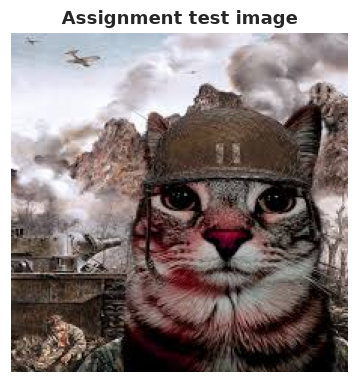

In [4]:
IMAGE_URL = ("https://encrypted-tbn2.gstatic.com/images?q=tbn:ANd9GcTznzGBwmeyPzcS3DldLO3g"
             "YhnS19JR5RJGltO1uVsNiIAxZA6y")

response = requests.get(IMAGE_URL, timeout=15)
response.raise_for_status()
cat_image = Image.open(io.BytesIO(response.content)).convert("RGB")

plt.figure(figsize=(4, 4))
plt.imshow(cat_image)
plt.axis("off")
plt.title("Assignment test image")
plt.show()


## 1. Using a Pre-trained ViT for Image Classification
We run the cat image through `ViTForImageClassification` and read off the top-1 label
from the model's 1000-way ImageNet head.

In [5]:
@torch.no_grad()
def predict_topk(image, model, processor, k=5):
    inputs = processor(images=image, return_tensors="pt").to(device)
    outputs = model(**inputs)
    probs = F.softmax(outputs.logits, dim=-1)[0]
    top_probs, top_idx = probs.topk(k)
    labels = [model.config.id2label[i.item()] for i in top_idx]
    return list(zip(labels, top_probs.cpu().numpy())), inputs


top5, vit_inputs = predict_topk(cat_image, vit_clf, processor, k=5)

print("Top-5 predictions:")
for label, prob in top5:
    print(f"  {label:35s} {100*prob:5.2f}%")

top1_label, top1_prob = top5[0]
print(f"\nTop-1 prediction: '{top1_label}' ({100*top1_prob:.2f}% confidence)")


Top-5 predictions:
  Egyptian cat                        33.17%
  tabby, tabby cat                    26.33%
  tiger cat                           22.98%
  lynx, catamount                      4.44%
  tiger, Panthera tigris               1.44%

Top-1 prediction: 'Egyptian cat' (33.17% confidence)


## 2. Visualizing Patch Attention
We re-run the forward pass with `output_attentions=True`, take the **final layer's**
attention tensor of shape `(batch, heads, seq_len, seq_len)` where `seq_len = 197`
(1 CLS token + 196 patch tokens), and read off the CLS token's attention **row**
(attention *from* CLS *to* every patch) **for a single attention head (Head 1, i.e. the
second head, zero-indexed)** rather than averaging across all heads -- this lets us look
at one head's behavior in isolation before comparing it against the other heads in Part 3.
That row is reshaped into the 14x14 patch grid and upsampled to the original 224x224
resolution to produce a heatmap overlay, alongside a raw (un-overlaid) heatmap of the
14x14 grid itself.

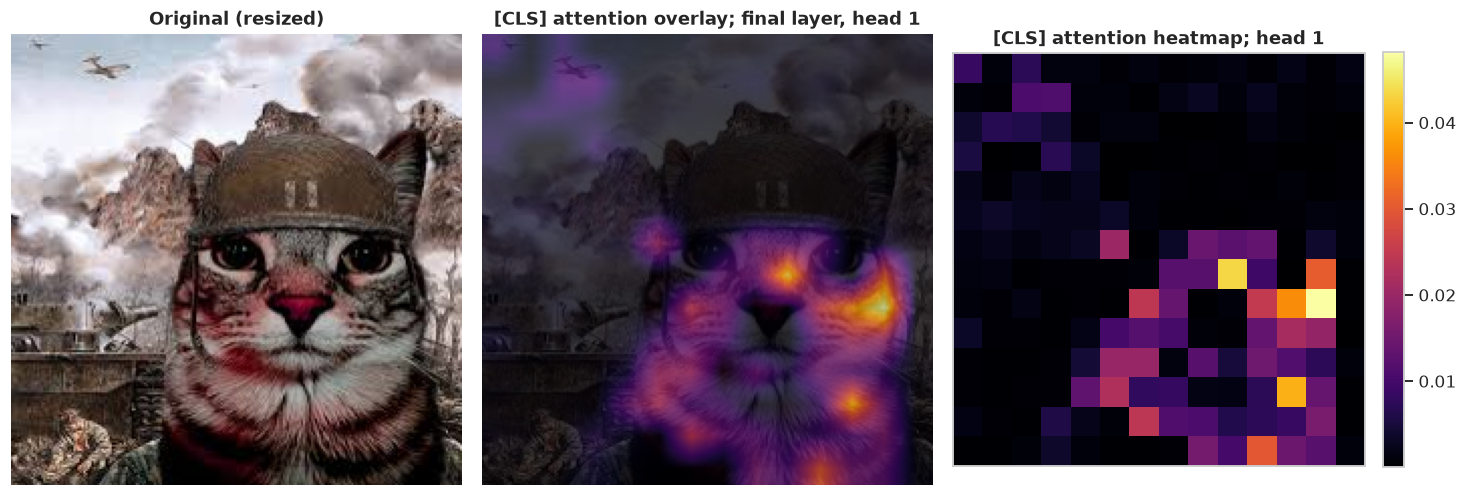

In [14]:
ATTN_HEAD = 1  # which attention head to visualize (zero-indexed)


@torch.no_grad()
def get_cls_attention_map(image, model, processor, layer=-1, head=None, head_reduction="mean"):
    '''Returns (attn_map_14x14, all_head_attn_14x14xheads, inputs, outputs).

    If `head` is given (an int), returns that single head's CLS attention map (no
    reduction across heads). Otherwise reduces across all heads via `head_reduction`
    ("mean" or "max").
    '''
    inputs = processor(images=image, return_tensors="pt").to(device)
    outputs = model(**inputs, output_attentions=True)
    attn = outputs.attentions[layer]              # (1, heads, seq, seq)
    attn = attn[0]                                  # (heads, seq, seq)

    cls_to_patches = attn[:, 0, 1:]                # (heads, num_patches) -- CLS row, drop CLS->CLS
    n_side = NUM_PATCHES_PER_SIDE
    per_head_maps = cls_to_patches.reshape(-1, n_side, n_side).cpu().numpy()  # (heads, 14, 14)

    if head is not None:
        attn_map = per_head_maps[head]
    elif head_reduction == "mean":
        attn_map = per_head_maps.mean(axis=0)
    elif head_reduction == "max":
        attn_map = per_head_maps.max(axis=0)
    else:
        raise ValueError(head_reduction)

    return attn_map, per_head_maps, inputs, outputs


def upsample_map(attn_map_14x14, out_size=IMG_SIZE):
    '''Upsample a (14, 14) attention map to (out_size, out_size) for overlay.'''
    t = torch.tensor(attn_map_14x14, dtype=torch.float32)[None, None]
    up = F.interpolate(t, size=(out_size, out_size), mode="bilinear", align_corners=False)
    return up[0, 0].numpy()


def overlay_heatmap(image, attn_map_14x14, ax=None, title=None, cmap="inferno", alpha=0.75):
    '''Overlay a normalized attention map on top of the (resized) original image.'''
    img_resized = image.resize((IMG_SIZE, IMG_SIZE))
    heat = upsample_map(attn_map_14x14)
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)

    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.imshow(img_resized)
    ax.imshow(heat, cmap=cmap, alpha=alpha)
    ax.axis("off")
    if title:
        ax.set_title(title)
    return ax


cls_attn_map, per_head_maps, vit_inputs, vit_outputs = get_cls_attention_map(
    cat_image, vit_clf, processor, layer=-1, head=ATTN_HEAD
)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))

axes[0].imshow(cat_image.resize((IMG_SIZE, IMG_SIZE)))
axes[0].axis("off")
axes[0].set_title("Original (resized)")

overlay_heatmap(cat_image, cls_attn_map, ax=axes[1],
                 title=f"[CLS] attention overlay; final layer, head {ATTN_HEAD}")

im = axes[2].imshow(cls_attn_map, cmap="inferno")
axes[2].set_title(f"[CLS] attention heatmap; head {ATTN_HEAD}")
axes[2].set_xticks([]); axes[2].set_yticks([])
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout(); plt.show()


## 3. Analyze the Attention Map

### Per-head specialization
To check whether individual attention heads specialize (e.g. some focus tightly on the
subject, others attend to background/edges), we plot the CLS attention map for
**every head in the final layer** separately.

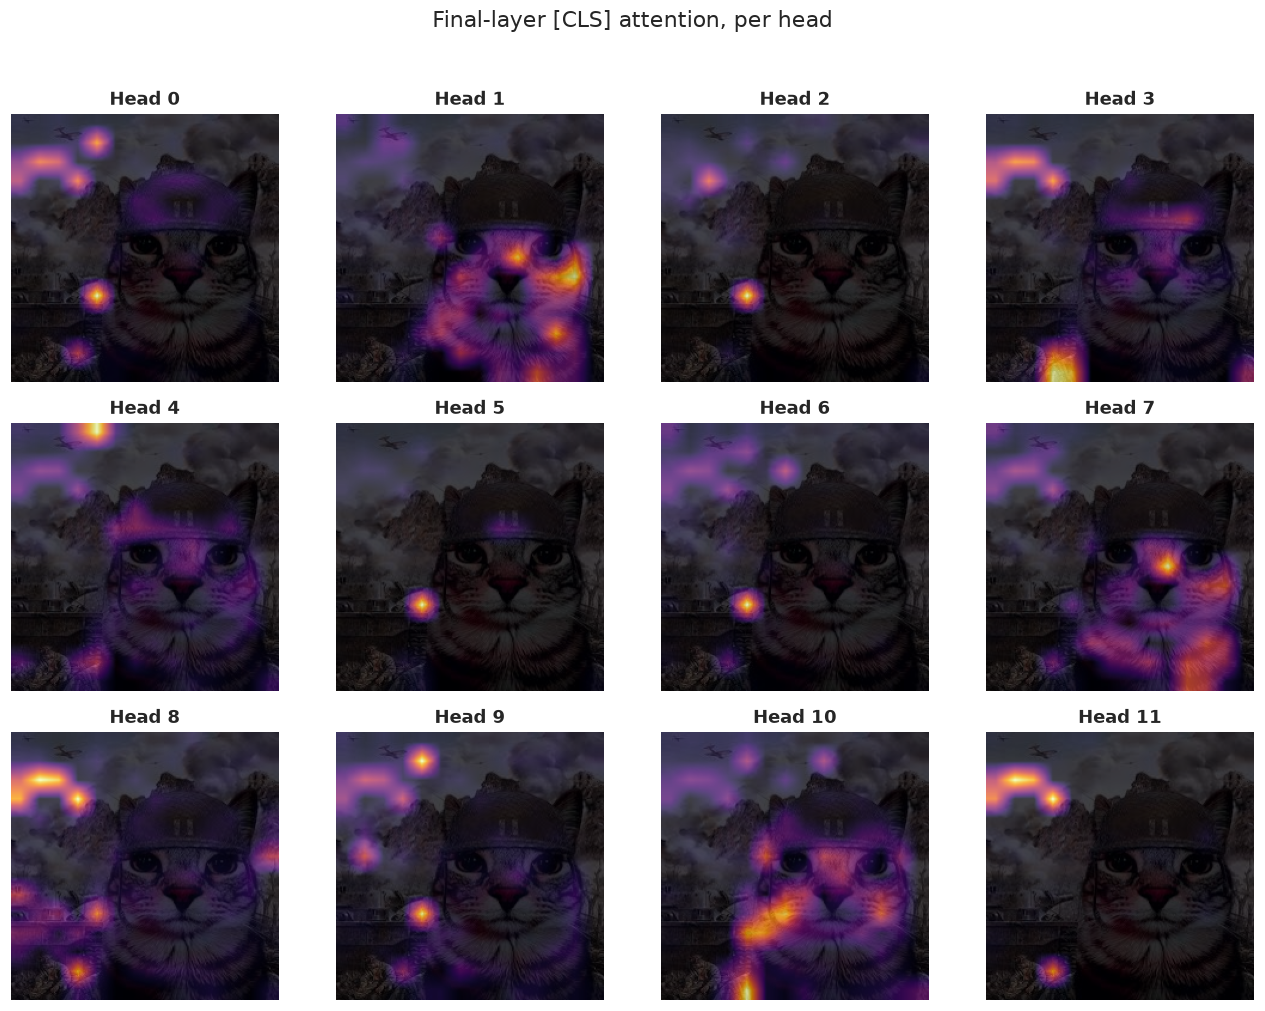

In [15]:
n_cols = 4
n_rows = int(np.ceil(NUM_HEADS / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 3.0 * n_rows))
axes = axes.flatten()

for h in range(NUM_HEADS):
    overlay_heatmap(cat_image, per_head_maps[h], ax=axes[h], title=f"Head {h}")
for h in range(NUM_HEADS, len(axes)):
    axes[h].axis("off")

fig.suptitle("Final-layer [CLS] attention, per head", y=1.02)
plt.tight_layout(); plt.show()


## 4. Patch-Masking Experiment
We mask a fraction of the 14x14 = 196 input patches (replacing masked patches with the
ImageNet mean-pixel value, i.e. zero in normalized space) and re-run classification,
sweeping the masked fraction from **0% to 100% in 10% increments**. Three masking
strategies are compared:

1. **Random masking** -- a uniformly random subset of patches is masked at each fraction
   (we average over several random trials for a stable estimate).
2. **Center masking** -- patches closest to the image center are masked first.
3. **Attention-guided masking** -- the patches the [CLS] token attends to *most strongly*
   (from Part 2's final-layer, Head 1 attention map) are masked first.

Since we only have one labeled test image, we use **top-1 label preservation** (does the
masked image still predict the same class as the original, unmasked image?) as our
"accuracy" proxy -- this is a standard robustness metric when ground-truth is unavailable.
We additionally track the softmax **confidence assigned to the original top-1 class** as a
continuous signal that is more informative than the binary preservation flag alone.

In [8]:
MEAN_PIXEL = torch.tensor(processor.image_mean).view(1, 3, 1, 1).to(device)


def mask_patches(pixel_values, patch_indices, patch_size=PATCH_SIZE, n_side=NUM_PATCHES_PER_SIDE):
    '''Replace the given flat patch indices (0..195) with the per-channel mean pixel value
    (i.e. a neutral / uninformative patch) in a copy of the (1, 3, H, W) normalized tensor.'''
    out = pixel_values.clone()
    for idx in patch_indices:
        r, c = divmod(int(idx), n_side)
        y0, y1 = r * patch_size, (r + 1) * patch_size
        x0, x1 = c * patch_size, (c + 1) * patch_size
        out[:, :, y0:y1, x0:x1] = MEAN_PIXEL
    return out


def center_order(n_side=NUM_PATCHES_PER_SIDE):
    '''Flat patch indices ordered by distance to the grid center (closest first).'''
    center = (n_side - 1) / 2
    coords = [(r, c) for r in range(n_side) for c in range(n_side)]
    dist = [((r - center) ** 2 + (c - center) ** 2, r * n_side + c) for r, c in coords]
    dist.sort(key=lambda t: t[0])
    return np.array([idx for _, idx in dist])


def attention_order(attn_map_14x14):
    '''Flat patch indices ordered by CLS attention, highest attention first.'''
    flat = attn_map_14x14.flatten()
    return np.argsort(-flat)


@torch.no_grad()
def predict_from_pixel_values(pixel_values, model):
    outputs = model(pixel_values=pixel_values)
    probs = F.softmax(outputs.logits, dim=-1)[0]
    top_idx = int(probs.argmax())
    return top_idx, probs[top_idx].item()


base_pixel_values = vit_inputs["pixel_values"]
orig_top_idx, orig_top_prob = predict_from_pixel_values(base_pixel_values, vit_clf)
print(f"Original top-1 class idx={orig_top_idx} "
      f"({vit_clf.config.id2label[orig_top_idx]}), prob={orig_top_prob:.4f}")

MASK_FRACTIONS = np.round(np.arange(0.0, 1.01, 0.1), 2)
N_RANDOM_TRIALS = 10

center_idx_order = center_order()
attn_idx_order = attention_order(cls_attn_map)

results_mask = {
    "random":    {"preserved": [], "confidence": []},
    "center":    {"preserved": [], "confidence": []},
    "attention": {"preserved": [], "confidence": []},
}

rng = np.random.default_rng(SEED)

for frac in tqdm(MASK_FRACTIONS, desc="Mask sweep"):
    n_mask = int(round(frac * NUM_PATCHES))

    # --- Random masking: average over several random trials ---
    preserved_trials, conf_trials = [], []
    for _ in range(N_RANDOM_TRIALS):
        rand_idx = rng.choice(NUM_PATCHES, size=n_mask, replace=False)
        masked = mask_patches(base_pixel_values, rand_idx)
        pred_idx, pred_conf = predict_from_pixel_values(masked, vit_clf)
        preserved_trials.append(float(pred_idx == orig_top_idx))
        probs = F.softmax(vit_clf(pixel_values=masked).logits, dim=-1)[0]
        conf_trials.append(probs[orig_top_idx].item())
    results_mask["random"]["preserved"].append(np.mean(preserved_trials))
    results_mask["random"]["confidence"].append(np.mean(conf_trials))

    # --- Center masking (deterministic) ---
    masked = mask_patches(base_pixel_values, center_idx_order[:n_mask])
    pred_idx, _ = predict_from_pixel_values(masked, vit_clf)
    probs = F.softmax(vit_clf(pixel_values=masked).logits, dim=-1)[0]
    results_mask["center"]["preserved"].append(float(pred_idx == orig_top_idx))
    results_mask["center"]["confidence"].append(probs[orig_top_idx].item())

    # --- Attention-guided masking (deterministic; mask highest-attention patches first) ---
    masked = mask_patches(base_pixel_values, attn_idx_order[:n_mask])
    pred_idx, _ = predict_from_pixel_values(masked, vit_clf)
    probs = F.softmax(vit_clf(pixel_values=masked).logits, dim=-1)[0]
    results_mask["attention"]["preserved"].append(float(pred_idx == orig_top_idx))
    results_mask["attention"]["confidence"].append(probs[orig_top_idx].item())

print("Done.")


Original top-1 class idx=285 (Egyptian cat), prob=0.3317


Mask sweep: 100%|██████████| 11/11 [00:04<00:00,  2.66it/s]

Done.


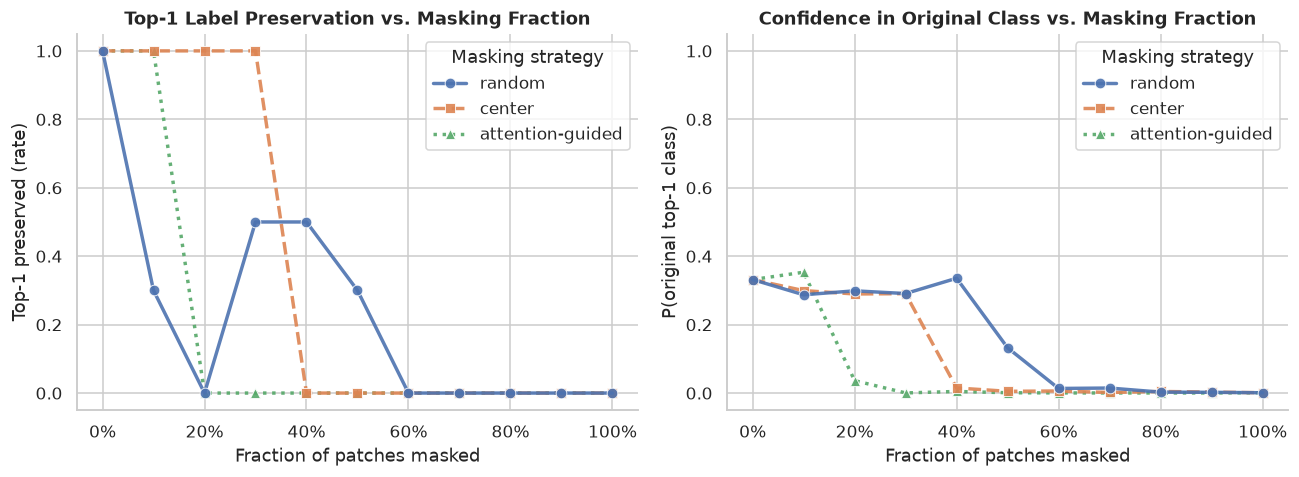

In [9]:
from matplotlib.ticker import PercentFormatter

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# NOTE: "center" and "attention-guided" masking are both deterministic (0/1 step
# functions), and for a roughly centered subject like our cat their patch orderings can
# be very similar -- so their curves can end up sitting exactly on top of one another.
# We give each strategy its own color, linestyle, and marker (rather than relying on
# color alone) so every curve stays visible even when values coincide.
strategy_style = {
    "random":    dict(color="C0", linestyle="-",  marker="o", label="random",           zorder=3),
    "center":    dict(color="C1", linestyle="--", marker="s", label="center",           zorder=2),
    "attention": dict(color="C2", linestyle=":",  marker="^", label="attention-guided", zorder=1),
}

for strategy, style in strategy_style.items():
    axes[0].plot(MASK_FRACTIONS, results_mask[strategy]["preserved"],
                 linewidth=2.25, markersize=7, markeredgecolor="white", markeredgewidth=0.6,
                 alpha=0.9, **style)
    axes[1].plot(MASK_FRACTIONS, results_mask[strategy]["confidence"],
                 linewidth=2.25, markersize=7, markeredgecolor="white", markeredgewidth=0.6,
                 alpha=0.9, **style)

axes[0].set_title("Top-1 Label Preservation vs. Masking Fraction")
axes[0].set_xlabel("Fraction of patches masked"); axes[0].set_ylabel("Top-1 preserved (rate)")
axes[0].xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(title="Masking strategy", frameon=True)

axes[1].set_title("Confidence in Original Class vs. Masking Fraction")
axes[1].set_xlabel("Fraction of patches masked"); axes[1].set_ylabel("P(original top-1 class)")
axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(title="Masking strategy", frameon=True)

sns.despine()
plt.tight_layout(); plt.show()


## 5. CLS Token vs. Mean-Pooled Patch Tokens
We now move to **CIFAR-10** and compare two ways of pooling the frozen ViT's final hidden
states into a single image embedding for a linear probe:

1. The **[CLS] token**'s final hidden state (the representation ImageNet classification
   normally reads from).
2. The **mean of all 196 patch tokens**' final hidden states (global average pooling over
   the sequence, ignoring CLS).

For feature extraction we use the base `ViTModel` (no classification head) so that both
pooling strategies read from the same frozen backbone, and train a simple linear layer
(logistic regression) as the probe on top of each.

In [16]:
vit_backbone = ViTModel.from_pretrained(MODEL_NAME).to(device)
vit_backbone.eval()
for p in vit_backbone.parameters():
    p.requires_grad = False

cifar_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

train_set = datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=cifar_tfms)
test_set  = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=cifar_tfms)

# Subsets for speed during development; increase for final results.
PROBE_TRAIN_SUBSET = 50000
PROBE_TEST_SUBSET = 10000

train_indices = np.random.choice(len(train_set), PROBE_TRAIN_SUBSET, replace=False)
test_indices  = np.random.choice(len(test_set), PROBE_TEST_SUBSET, replace=False)

probe_train_loader = DataLoader(Subset(train_set, train_indices), batch_size=64, shuffle=False, num_workers=0)
probe_test_loader  = DataLoader(Subset(test_set,  test_indices),  batch_size=64, shuffle=False, num_workers=0)

classes = train_set.classes
print(classes)
print(f"Probe train: {len(train_indices)} | Probe test: {len(test_indices)}")


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/mnt/Windows/Ayaan files/parhai/uni/3 fall/ATML/PA0/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Probe train: 50000 | Probe test: 10000


In [17]:
@torch.no_grad()
def extract_cls_and_mean_features(loader, model):
    cls_feats, mean_feats, labels = [], [], []
    for imgs, labs in tqdm(loader, desc="Extracting features", leave=False):
        imgs = imgs.to(device)
        out = model(pixel_values=imgs)
        hidden = out.last_hidden_state          # (B, 197, 768)
        cls_feats.append(hidden[:, 0, :].cpu().numpy())          # CLS token
        mean_feats.append(hidden[:, 1:, :].mean(dim=1).cpu().numpy())  # mean-pooled patches
        labels.append(labs.numpy())
    return (np.concatenate(cls_feats), np.concatenate(mean_feats), np.concatenate(labels))


train_cls_feats, train_mean_feats, train_labels = extract_cls_and_mean_features(probe_train_loader, vit_backbone)
test_cls_feats,  test_mean_feats,  test_labels  = extract_cls_and_mean_features(probe_test_loader,  vit_backbone)

print("CLS feature shape:", train_cls_feats.shape)
print("Mean-pooled feature shape:", train_mean_feats.shape)


CLS feature shape: (50000, 768)
Mean-pooled feature shape: (50000, 768)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


def train_linear_probe(train_feats, train_labels, test_feats, test_labels):
    scaler = StandardScaler().fit(train_feats)
    train_scaled = scaler.transform(train_feats)
    test_scaled = scaler.transform(test_feats)

    # Note: recent scikit-learn versions (>=1.5) removed the `multi_class` kwarg --
    # the default "lbfgs" solver already fits a multinomial model for >2 classes.
    clf = LogisticRegression(max_iter=2000)
    clf.fit(train_scaled, train_labels)

    train_acc = 100 * accuracy_score(train_labels, clf.predict(train_scaled))
    test_acc = 100 * accuracy_score(test_labels, clf.predict(test_scaled))
    return clf, train_acc, test_acc


cls_clf, cls_train_acc, cls_test_acc = train_linear_probe(
    train_cls_feats, train_labels, test_cls_feats, test_labels
)
mean_clf, mean_train_acc, mean_test_acc = train_linear_probe(
    train_mean_feats, train_labels, test_mean_feats, test_labels
)

print(f"[CLS token]        train acc = {cls_train_acc:.2f}% | test acc = {cls_test_acc:.2f}%")
print(f"[Mean-pooled patch] train acc = {mean_train_acc:.2f}% | test acc = {mean_test_acc:.2f}%")


[CLS token]        train acc = 99.70% | test acc = 95.88%
[Mean-pooled patch] train acc = 99.71% | test acc = 96.26%


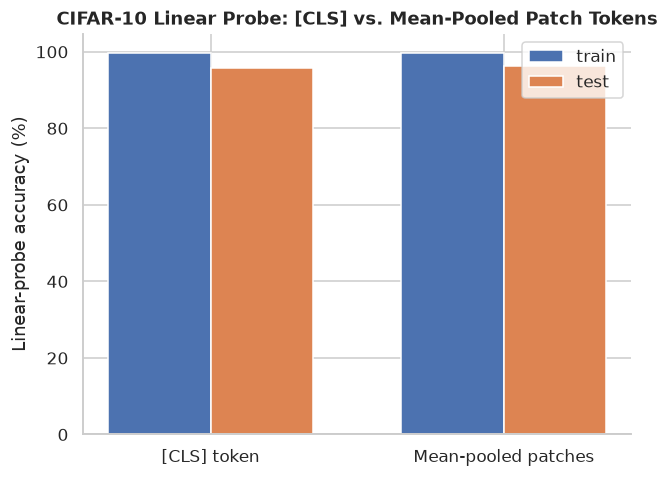

In [19]:
probe_summary = {
    "[CLS] token": {"train": cls_train_acc, "test": cls_test_acc},
    "Mean-pooled patches": {"train": mean_train_acc, "test": mean_test_acc},
}

fig, ax = plt.subplots(figsize=(6, 4.5))
x = np.arange(len(probe_summary))
width = 0.35

train_vals = [v["train"] for v in probe_summary.values()]
test_vals = [v["test"] for v in probe_summary.values()]

ax.bar(x - width/2, train_vals, width, label="train")
ax.bar(x + width/2, test_vals, width, label="test")
ax.set_xticks(x)
ax.set_xticklabels(probe_summary.keys())
ax.set_ylabel("Linear-probe accuracy (%)")
ax.set_title("CIFAR-10 Linear Probe: [CLS] vs. Mean-Pooled Patch Tokens")
ax.legend(frameon=True)
sns.despine()
plt.tight_layout(); plt.show()
